In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer, QuantileTransformer,
    OneHotEncoder, OrdinalEncoder, PolynomialFeatures, FunctionTransformer, KBinsDiscretizer
)
from sklearn.feature_extraction import FeatureHasher


In [58]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [59]:
if 'ID' in df.columns:
    df = df.drop('ID',axis=1)
targer_col = 'Reached.on.Time_Y.N'
x = df.drop(targer_col, axis =1)
y = df[targer_col]

print(f"Features Shape: {x.head()}")
print(f"Target Shape: {y.tail()}")

Features Shape:   Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0               D           Flight                    4                2   
1               F           Flight                    4                5   
2               A           Flight                    2                2   
3               B           Flight                    3                3   
4               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  
0                44           1233  
1                59           3088  
2

In [60]:
x.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,D,Flight,4,2,177,3,low,F,44,1233
1,F,Flight,4,5,216,2,low,M,59,3088
2,A,Flight,2,2,183,4,low,M,48,3374
3,B,Flight,3,3,176,4,medium,M,10,1177
4,C,Flight,2,2,184,3,medium,F,46,2484


In [62]:
importance_mapping={
    'low':1,
    'medium':2,
    'high':3
}


In [63]:
x['Product_importance']=x['Product_importance'].map(importance_mapping)

In [64]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
x['Gender'] = encoder.fit_transform(
    x['Gender'])

In [67]:
f_hash = x['Mode_of_Shipment'].astype(str).apply(lambda val: [val])
hasher = FeatureHasher(n_features=4, input_type='string')
hashed_f = hasher.transform(f_hash)
hashed_df = pd.DataFrame(
    hashed_f.toarray(),
    columns=[f"Mode_of_Shipment_hash_{i}" for i in range(4)]
)

In [68]:
f_hash_warehouse = x['Warehouse_block'].astype(str).apply(lambda val: [val])
hasher_warehouse = FeatureHasher(n_features=6, input_type='string')
hashed_f_warehouse = hasher_warehouse.transform(f_hash_warehouse)
hashed_df_warehouse = pd.DataFrame(
    hashed_f_warehouse.toarray(),
    columns=[f"Warehouse_block_hash_{i}" for i in range(6)]
)

In [77]:

x = pd.concat([x, hashed_df_warehouse,hashed_df], axis=1)

   Customer_care_calls  Customer_rating  Cost_of_the_Product  Prior_purchases  \
0                    4                2                  177                3   
1                    4                5                  216                2   
2                    2                2                  183                4   
3                    3                3                  176                4   
4                    2                2                  184                3   

   Product_importance  Gender  Discount_offered  Weight_in_gms  \
0                   1       0                44           1233   
1                   1       1                59           3088   
2                   1       1                48           3374   
3                   2       1                10           1177   
4                   2       0                46           2484   

   Warehouse_block_hash_0  Warehouse_block_hash_1  Warehouse_block_hash_2  \
0                     0.0              

In [78]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=30)


In [84]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [87]:
y_pred = xgb_model.predict(X_test)

In [86]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.675


In [88]:
print("Report:", classification_report(y_test, y_pred))

Report:               precision    recall  f1-score   support

           0       0.56      0.89      0.68       874
           1       0.88      0.54      0.67      1326

    accuracy                           0.68      2200
   macro avg       0.72      0.71      0.67      2200
weighted avg       0.75      0.68      0.67      2200



In [91]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[775  99]
 [616 710]]


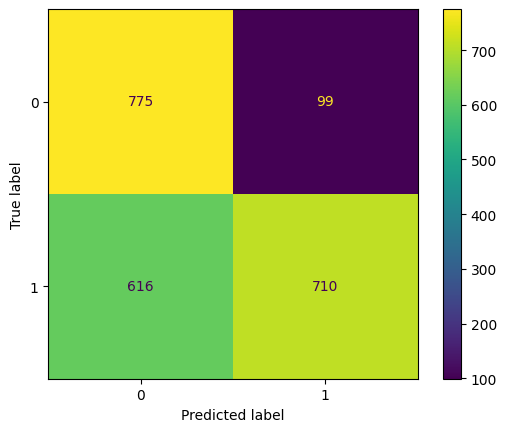

In [92]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()